In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier

import h5py
import sys
import umap
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm


In [2]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:
seed = 0
from src.data.modules.LitData  import LitData
from src.data.modules.LitPretrain import LitPretrain
from torchvision.transforms import Compose
from src.augmentations import LightCurveTransform as LC
args = {'general':{}}
#args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 128

pl_datal = LitPretrain(transform_1=Compose([]),**args['general'])
dataloader = pl_datal.val_dataloader() 

TypeError: LitPretrain.__init__() got an unexpected keyword argument 'transform_1'

  0%|          | 0/558 [00:00<?, ?it/s]


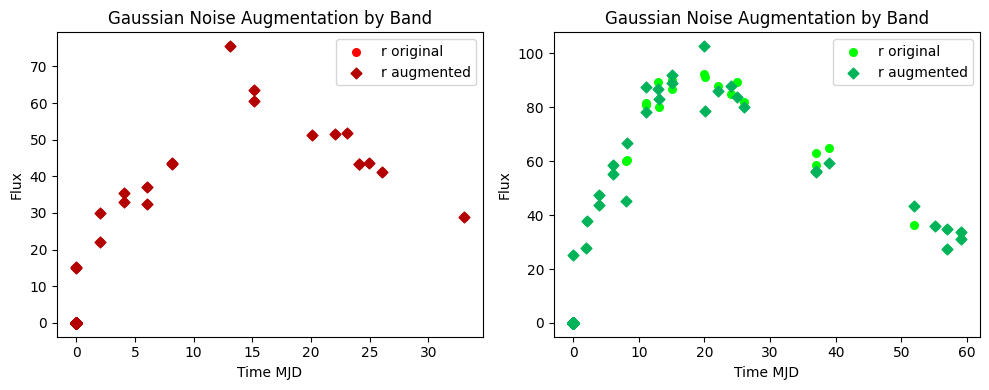

  0%|          | 0/558 [00:00<?, ?it/s]


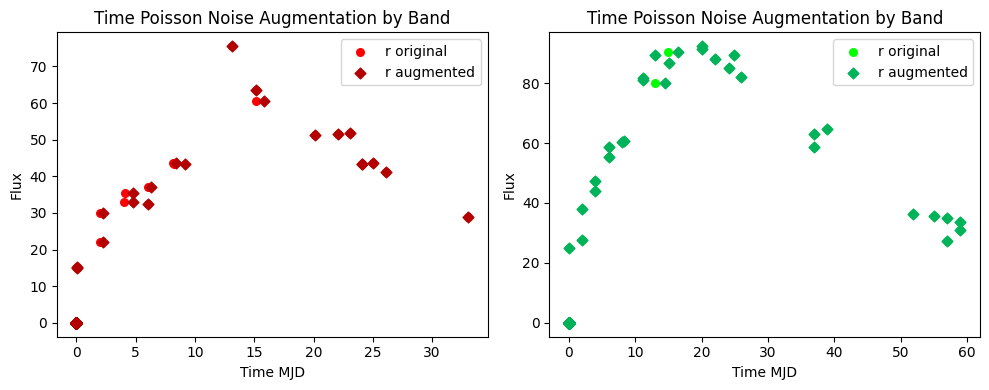

  0%|          | 0/558 [00:00<?, ?it/s]


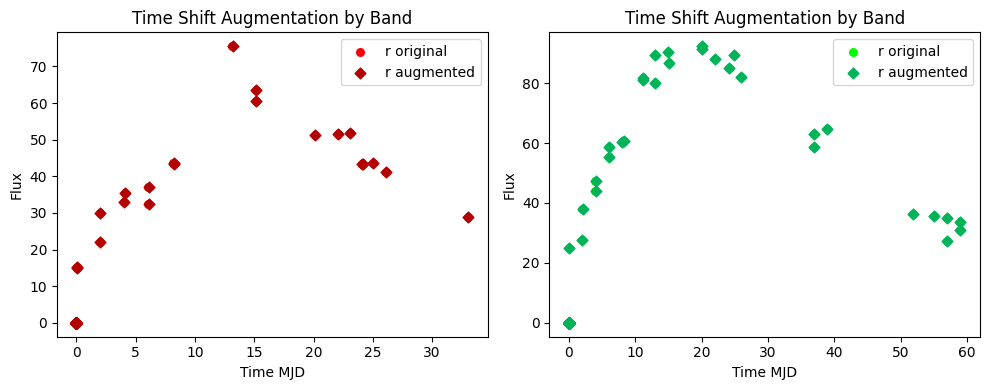

  0%|          | 0/558 [00:00<?, ?it/s]


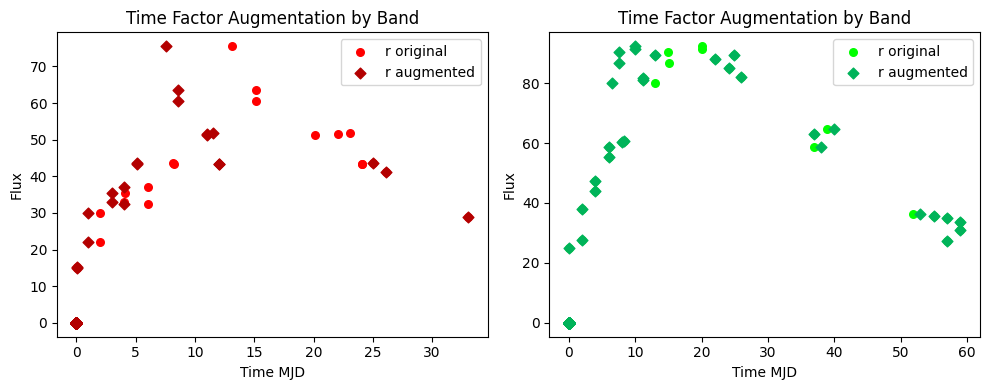

  0%|          | 0/558 [00:00<?, ?it/s]


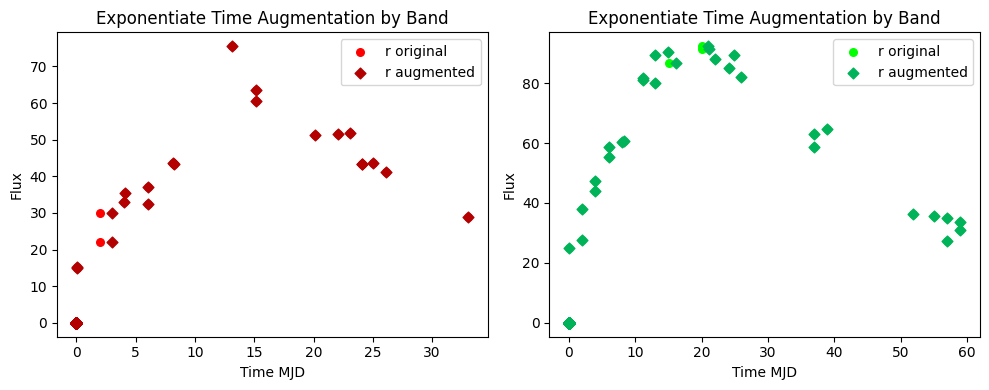

In [20]:
import seaborn as sns
from copy import deepcopy
  
def plot_augmentation(augmentation,title = '', n = 0):
    for b1 in tqdm(dataloader):
        b1 = {k: b1[k].float()[n,:,:] for k in b1.keys()}
        b2 = deepcopy(b1)
        
        b2 = augmentation(b2) 
        break
    fig = plt.figure(figsize= (10,4))

    ax1 = fig.add_subplot(121)
    seqlen = 200

    alpha = 0.9
    red =  '#ff0000'
    green =  '#00ff00'
    
    dark_red = '#b30000'
    dark_green = '#00b35a'
    
    ax1.scatter(x = b1['time'][:seqlen,0],y = b1['data'][:seqlen,0],marker = 'o',s = 30, color = red)
    #ax1.scatter(x = b1['time'][:seqlen,1],y = b1['data'][:seqlen,1],marker = 'o',s = 30, color =green,)

    ax1.scatter(x = b2['time'][:seqlen,0],y = b2['data'][:seqlen,0],marker = 'D',s = 30, color = dark_red)
    #ax1.scatter(x = b2['time'][:seqlen,1],y = b2['data'][:seqlen,1],marker = 'D',s = 30, color = dark_green)
    plt.legend(['r original','r augmented',"g original",'g augmented'])

    plt.ylabel('Flux')
    plt.xlabel('Time MJD')
    plt.title(title)
    #ax1.set_xscale('log')
    #plt.show()
    
    
    ax2 = fig.add_subplot(122)
    
    
    #ax2.scatter(x = b1['time'][:seqlen,0],y = b1['data'][:seqlen,0],marker = 'o',s = 30, color = red)
    ax2.scatter(x = b1['time'][:seqlen,1],y = b1['data'][:seqlen,1],marker = 'o',s = 30, color =green,)

    #ax2.scatter(x = b2['time'][:seqlen,0],y = b2['data'][:seqlen,0],marker = 'D',s = 30, color = dark_red)
    ax2.scatter(x = b2['time'][:seqlen,1],y = b2['data'][:seqlen,1],marker = 'D',s = 30, color = dark_green)
    plt.legend(['r original','r augmented',"g original",'g augmented'])
    plt.ylabel('Flux')
    plt.xlabel('Time MJD')
    plt.title(title + '')
    #ax1.set_xscale('log')
    plt.tight_layout()

    plt.show()


WINDOW = 3
N = 61

plot_augmentation(Compose([LC.GaussianNoise(2,window=WINDOW)]), 'Gaussian Noise Augmentation by Band',n = N)
plot_augmentation(Compose([LC.TimePoissonNoise(2,rate = 1,window=WINDOW)]), 'Time Poisson Noise Augmentation by Band',n = N)

plot_augmentation(Compose([LC.TimeShift(2,window=WINDOW)]), 'Time Shift Augmentation by Band',n = N)
plot_augmentation(Compose([LC.TimeFactor(2,window=WINDOW),
                           LC.Exptime(2,window=WINDOW)]), 'Time Factor Augmentation by Band',n = N)
plot_augmentation(Compose([LC.Exptime(2,window=WINDOW)]), 'Exponentiate Time Augmentation by Band',n = N)


In [6]:
def graph_count(dataloader,set_type):
    r_band_count = []
    g_band_count = []
    
    for b1 in tqdm(dataloader):
        n= np.random.randint(0,128)
        b1 = {k: b1[k].float() for k in b1.keys()}
        
        b2 = {k: b1[k].clone().float() for k in b1.keys()}

        r_band_count+=[b1['mask'][:,:,0].sum(dim  = -1).flatten(-1).numpy().tolist()]
        
        g_band_count+=[b1['mask'][:,:,1].sum(dim  = -1).flatten(-1).numpy().tolist()]
    fig = plt.figure(figsize = (10,4))
    ax = fig.add_subplot(121)
    bins_r = np.concatenate([r_band_count]).reshape(-1)
    bins_g = np.concatenate([g_band_count]).reshape(-1)

    print((bins_r >= 10).sum())
    print((bins_g >= 10).sum())
    print(bins_r.mean(),'+/-',bins_r.std())
    print(bins_g.mean(),'+/-',bins_g.std())


    sns.histplot(bins_r, color = 'green',ax = ax, bins = 100, alpha = 0.8)
    sns.histplot(bins_g, color = 'red', ax = ax, bins = 100, alpha = 0.8)
    plt.xlabel('bins')
    ax.set_yscale('log')
    ax = fig.add_subplot(122)
    sns.histplot(bins_r, color = 'green',ax = ax, bins = 100, alpha = 0.8)
    sns.histplot(bins_g, color = 'red', ax = ax, bins = 100, alpha = 0.8)
    plt.xlim(-1,50)
    plt.xlabel('bins')
    ax.set_yscale('log')
    plt.suptitle(f'LC Samples Histogram n: {bins_r.shape[0]} {set_type}')
    plt.tight_layout()
    plt.show()
    #sns.histplot(bins,bins = 10)

True
full dataset size: 286178
NOT USING SAMPLER FOR DATASET train


100%|██████████| 2235/2235 [00:28<00:00, 77.22it/s] 


79133
88942
12.169508529082774 +/- 23.525689007651668
13.84233081655481 +/- 26.17112739040807


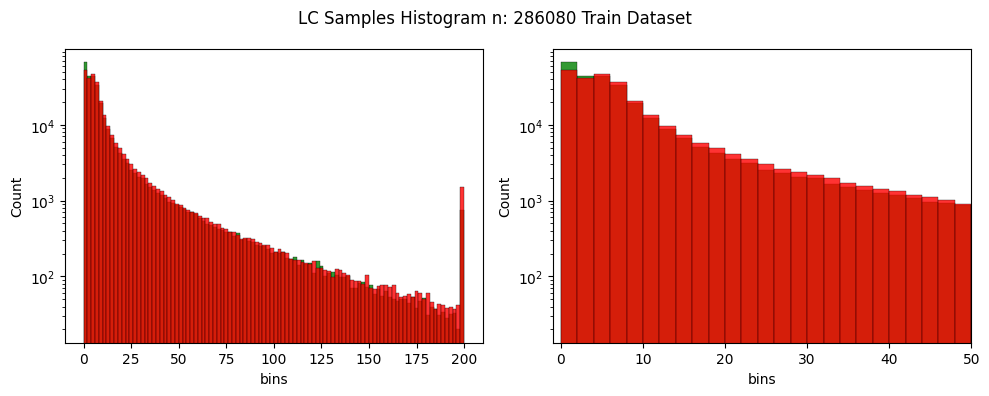

In [7]:
dataloader = pl_datal.train_dataloader() 
graph_count(dataloader, 'Train Dataset')

NOT USING SAMPLER FOR DATASET validation


100%|██████████| 558/558 [00:06<00:00, 81.39it/s] 


19844
22221
12.108562948028673 +/- 23.525597630670767
13.89605734767025 +/- 26.419404604430913


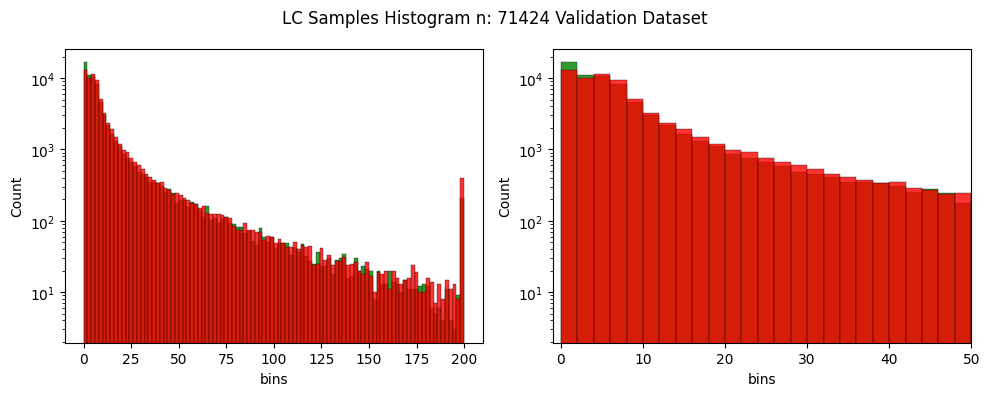

In [8]:
dataloader = pl_datal.val_dataloader() 
graph_count(dataloader, 'Validation Dataset')

  0%|          | 0/558 [00:00<?, ?it/s]


<Axes: >

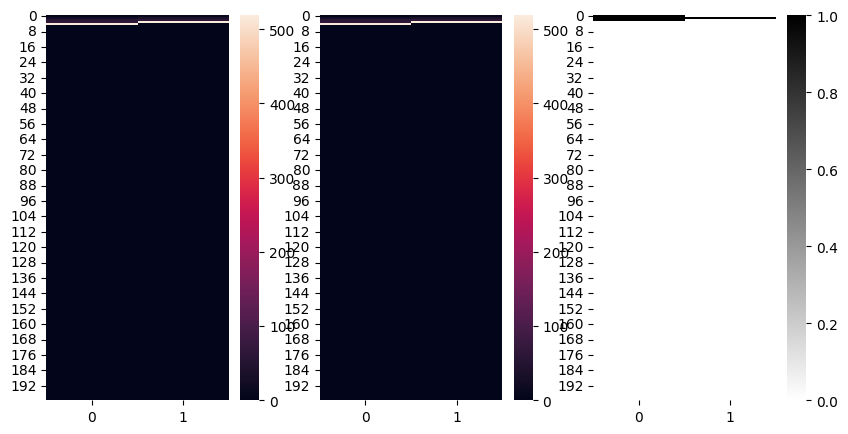

In [9]:
transform = Compose([LC.Exptime(num_bands = 2,window = 3)])
for b1 in tqdm(dataloader):
    n= np.random.randint(0,128)
    b1 = {k: b1[k].float()[n,:,:] for k in b1.keys()}
    b2 = {k: b1[k].clone().float() for k in b1.keys()}
    
    b2 = transform(b2) 
    b1 = b1
    break

import seaborn as sns

b1 = b1
b2 = b2

fig = plt.figure(figsize= (10,5))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

sns.heatmap(b1['time'],ax = ax1)
sns.heatmap(b2['time'],ax = ax2)
sns.heatmap((b1['time'] - b2['time'])!=0,cmap = 'binary',ax = ax3)